# TuneTale: KNN Testing & Evaluation

Loads the preprocessed training CSV from `eda.ipynb`, fits KNN, and evaluates recommendations using MeanDistance@K and Precision@K (genre match rate).

In [100]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler
from sklearn.neighbors import NearestNeighbors
import matplotlib.pyplot as plt
import time

## 1. Load Raw Data & Build Baseline

Loads `data/tracks.csv` and constructs two datasets:
- **Baseline**: 5 features, duplicates retained. Isolates the effect of deduplication
- **Optimized**: 9 features, deduplicated by track ID then by track name + artist

In [101]:
RAW_CSV = "data/tracks.csv"

FEATURES_5 = ["danceability", "energy", "loudness", "valence", "tempo"]
FEATURES_9 = ["danceability", "energy", "loudness", "valence", "tempo",
               "acousticness", "speechiness", "instrumentalness", "liveness"]
K = 10

raw = pd.read_csv(RAW_CSV)
print(f"Raw dataset: {len(raw):,} tracks, {raw['track_genre'].nunique()} genres")

# ── Baseline: 5 features, duplicates retained ────────────────────────────────
metadata = ["track_id", "track_name", "artists", "track_genre"]
df_base = raw[metadata + FEATURES_5].dropna().reset_index(drop=True)
scaler_base = MinMaxScaler()
df_base[FEATURES_5] = scaler_base.fit_transform(df_base[FEATURES_5])
X_base = df_base[FEATURES_5].values

print(f"Baseline dataset  : {len(df_base):,} tracks (duplicates retained)")
df_base.head()

Raw dataset: 114,000 tracks, 114 genres
Baseline dataset  : 113,999 tracks (duplicates retained)


,track_id,track_name,artists,track_genre,danceability,energy,loudness,valence,tempo
0,5SuOikwiRyPMVoIQDJUgSV,Comedy,Gen Hoshino,acoustic,0.686294,0.4610,0.791392,0.718593,0.361245
1,4qPNDBW1i3p13qLCt0Ki3A,Ghost - Acoustic,Ben Woodward,acoustic,0.426396,0.1660,0.597377,0.268342,0.318397
2,1iJBSr7s7jYXzM8EGcbK5b,To Begin Again,Ingrid Michaelson;ZAYN,acoustic,0.444670,0.3590,0.736123,0.120603,0.313643
3,6lfxq3CG4xtTiEg7opyCyx,Can't Help Falling In Love,Kina Grannis,acoustic,0.270051,0.0596,0.573701,0.143719,0.746758
4,5vjLSffimiIP26QG5WcN2K,Hold On,Chord Overstreet,acoustic,0.627411,0.4430,0.737103,0.167839,0.492863


## 2. Optimized Dataset & Fit KNN Models

In [102]:
df_opt = raw[["track_id", "track_name", "artists", "album_name", "track_genre"] + FEATURES_9].dropna()
df_opt = df_opt.drop_duplicates(subset="track_id")
df_opt = df_opt.drop_duplicates(subset=["track_name", "artists"]).reset_index(drop=True)
scaler_opt = MinMaxScaler()
df_opt[FEATURES_9] = scaler_opt.fit_transform(df_opt[FEATURES_9])
X_opt = df_opt[FEATURES_9].values

print(f"Optimized dataset : {len(df_opt):,} tracks")

# Aliases used by the recommendation function
df = df_opt
X  = X_opt

# Fit all three KNN models
knn_base = NearestNeighbors(n_neighbors=K+1,    metric="euclidean", algorithm="ball_tree").fit(X_base)
knn_opt  = NearestNeighbors(n_neighbors=K+1,    metric="euclidean", algorithm="ball_tree").fit(X_opt)
knn_gf   = NearestNeighbors(n_neighbors=K*20+1, metric="euclidean", algorithm="ball_tree").fit(X_opt)
knn      = knn_opt  # default for recommend()

print("KNN models fitted.")

Optimized dataset : 81,343 tracks
KNN models fitted.


## 3. Recommendation Function

In [103]:
def recommend(song_name, artist_name=None, n=K, genre_filter=False):
    mask = df["track_name"].str.lower() == song_name.lower()
    if artist_name:
        mask &= df["artists"].str.lower().str.contains(artist_name.lower())

    matches = df[mask]
    if matches.empty:
        print(f"'{song_name}' not found in dataset.")
        return None

    idx = matches.index[0]
    query_genre = df.at[idx, "track_genre"]

    if genre_filter:
        distances, indices = knn_gf.kneighbors(X[idx].reshape(1, -1))
        candidates = [(i, d) for i, d in zip(indices[0][1:], distances[0][1:])
                      if df.at[i, "track_genre"] == query_genre][:n]
        if not candidates:
            print(f"No same-genre results found for genre '{query_genre}'.")
            return None
        neighbor_idx  = [c[0] for c in candidates]
        neighbor_dist = [c[1] for c in candidates]
    else:
        distances, indices = knn.kneighbors(X[idx].reshape(1, -1))
        neighbor_idx  = list(indices[0][1:n+1])
        neighbor_dist = list(distances[0][1:n+1])

    results = df.iloc[neighbor_idx][["track_name", "artists", "track_genre"]].copy()
    results["distance"] = [round(d, 4) for d in neighbor_dist]
    results = results.reset_index(drop=True)
    results.index += 1

    label = f"genre-filtered ({query_genre})" if genre_filter else "all genres"
    print(f"Query: '{df.at[idx, 'track_name']}' by {df.at[idx, 'artists']} [{query_genre}] — {label}\n")
    return results

## 4. Evaluation

Three metrics averaged over a random sample of **n = 70,000** songs:

- **Genre Precision@K**: fraction of K neighbors sharing the query's exact genre
- **Diversity**: mean pairwise Euclidean distance among the K neighbors (higher = more varied)
- **Same-Artist Rate**: fraction of K neighbors by the same artist as the query (lower = better discovery)

In [107]:
N_EVAL = 70000
SEED   = 42


def evaluate_vectorized(df_eval, X_eval, knn_model, label, n_eval=N_EVAL, seed=SEED):
    print(f"Evaluating {label}")
    t0 = time.time()
    rng = np.random.default_rng(seed)
    sample_idx = rng.choice(len(df_eval), size=min(n_eval, len(df_eval)), replace=False)

    _, indices_all = knn_model.kneighbors(X_eval[sample_idx])
    nbr_idx = indices_all[:, 1:K+1]

    genres  = np.array(df_eval["track_genre"].values)
    artists = np.array(df_eval["artists"].values)

    genre_precision  = (genres[nbr_idx]  == genres[sample_idx, None]).mean()
    same_artist_rate = (artists[nbr_idx] == artists[sample_idx, None]).mean()

    X_nbrs = X_eval[nbr_idx]
    ti, tj = np.triu_indices(K, k=1)
    diff = X_nbrs[:, ti, :] - X_nbrs[:, tj, :]
    diversity = np.sqrt((diff**2).sum(axis=2)).mean()

    print(f"  Genre Precision : {genre_precision*100:.1f}%")
    print(f"  Diversity       : {diversity:.4f}")
    print(f"  Same-Artist Rate: {same_artist_rate*100:.1f}%")
    print(f"  Time: {time.time()-t0:.1f}s\n")
    return genre_precision, diversity, same_artist_rate


def evaluate_genre_filtered(df_eval, X_eval, knn_gf_model, n_eval=N_EVAL, seed=SEED):
    print("Evaluating Genre-Filtered")
    t0 = time.time()
    rng = np.random.default_rng(seed)
    sample_idx = rng.choice(len(df_eval), size=min(n_eval, len(df_eval)), replace=False)

    _, indices_all = knn_gf_model.kneighbors(X_eval[sample_idx])
    cand_idx = indices_all[:, 1:]

    genres  = np.array(df_eval["track_genre"].values)
    artists = np.array(df_eval["artists"].values)

    div_scores = []
    sa_scores  = []
    for qi, i in enumerate(sample_idx):
        sg = cand_idx[qi][genres[cand_idx[qi]] == genres[i]][:K]
        if len(sg) < 2:
            continue
        sa_scores.append((artists[sg] == artists[i]).mean())
        vecs = X_eval[sg]
        ti, tj = np.triu_indices(len(vecs), k=1)
        div_scores.append(np.sqrt(((vecs[ti]-vecs[tj])**2).sum(axis=1)).mean())

    diversity        = float(np.mean(div_scores))
    same_artist_rate = float(np.mean(sa_scores))
    valid = len(div_scores)
    print(f"  Genre Precision : 100.0% (by construction)")
    print(f"  Diversity       : {diversity:.4f}")
    print(f"  Same-Artist Rate: {same_artist_rate*100:.1f}%")
    print(f"  Valid queries   : {valid:,} / {n_eval:,} ({valid/n_eval*100:.1f}%)")
    print(f"  Time: {time.time()-t0:.1f}s\n")
    return 1.0, diversity, same_artist_rate


# ── Run all three evaluations ─────────────────────────────────────────────────
gp_b, div_b, sa_b = evaluate_vectorized(df_base, X_base, knn_base,
                                         "Baseline  (5 features, with duplicates)")
gp_o, div_o, sa_o = evaluate_vectorized(df_opt,  X_opt,  knn_opt,
                                         "Optimized (9 features, deduplicated)")
gp_g, div_g, sa_g = evaluate_genre_filtered(df_opt, X_opt, knn_gf)

print("=" * 60)
print(f"{'Stage':<22} {'Genre Prec':>10} {'Diversity':>10} {'Same Art':>10}")
print("=" * 60)
print(f"{'Baseline':<22} {gp_b*100:>9.1f}% {div_b:>10.4f} {sa_b*100:>9.1f}%")
print(f"{'Optimized':<22} {gp_o*100:>9.1f}% {div_o:>10.4f} {sa_o*100:>9.1f}%")
print(f"{'Genre-Filtered':<22} {gp_g*100:>9.1f}% {div_g:>10.4f} {sa_g*100:>9.1f}%")
print("=" * 60)

Evaluating Baseline  (5 features, with duplicates)
  Genre Precision : 11.9%
  Diversity       : 0.0530
  Same-Artist Rate: 14.5%
  Time: 12.3s

Evaluating Optimized (9 features, deduplicated)
  Genre Precision : 11.0%
  Diversity       : 0.1582
  Same-Artist Rate: 1.4%
  Time: 25.5s

Evaluating Genre-Filtered
  Genre Precision : 100.0% (by construction)
  Diversity       : 0.2178
  Same-Artist Rate: 6.6%
  Valid queries   : 59,704 / 70,000 (85.3%)
  Time: 47.6s

Stage                  Genre Prec  Diversity   Same Art
Baseline                    11.9%     0.0530      14.5%
Optimized                   11.0%     0.1582       1.4%
Genre-Filtered             100.0%     0.2178       6.6%


## 5. Score Distribution Graph

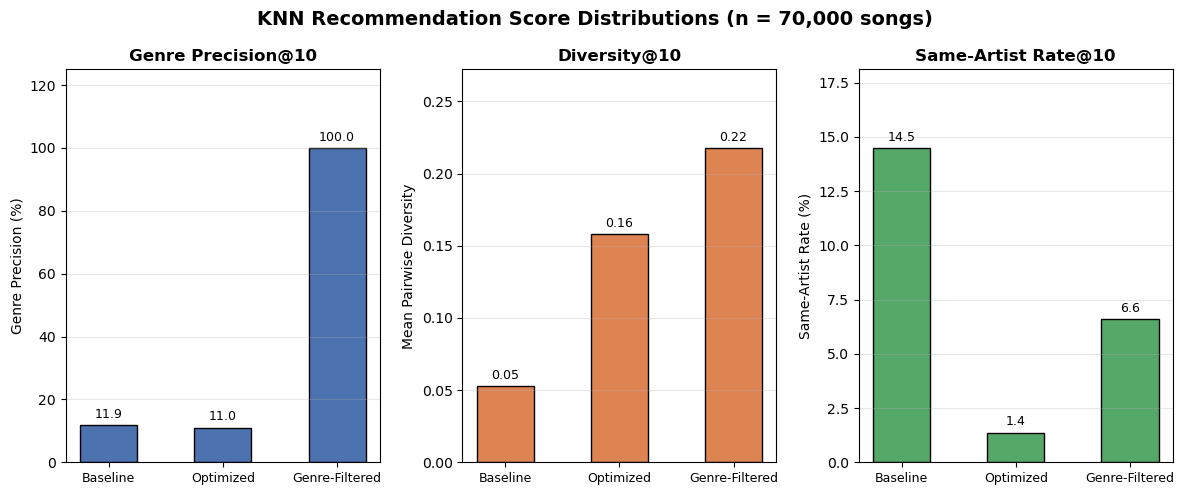

In [108]:
stages  = ["Baseline", "Optimized", "Genre-Filtered"]
results = {
    "Baseline":       (gp_b, div_b, sa_b),
    "Optimized":      (gp_o, div_o, sa_o),
    "Genre-Filtered": (gp_g, div_g, sa_g),
}

gps  = [results[s][0] * 100 for s in stages]
divs = [results[s][1]       for s in stages]
sas  = [results[s][2] * 100 for s in stages]

x      = np.arange(len(stages))
colors = ["#4C72B0", "#DD8452", "#55A868"]

fig, axes = plt.subplots(1, 3, figsize=(12, 5))
fig.suptitle(f"KNN Recommendation Score Distributions (n = {N_EVAL:,} songs)",
             fontsize=14, fontweight="bold")

for ax, values, ylabel, title, color in zip(
    axes,
    [gps, divs, sas],
    ["Genre Precision (%)", "Mean Pairwise Diversity", "Same-Artist Rate (%)"],
    ["Genre Precision@10", "Diversity@10", "Same-Artist Rate@10"],
    colors,
):
    bars = ax.bar(x, values, color=color, edgecolor="black", width=0.5)
    ax.set_xticks(x)
    ax.set_xticklabels(stages, fontsize=9)
    ax.set_ylabel(ylabel)
    ax.set_title(title, fontweight="bold")
    fmt = "%.2f" if max(values) < 5 else "%.1f"
    ax.bar_label(bars, fmt=fmt, padding=3, fontsize=9)
    ax.set_ylim(0, max(values) * 1.25)
    ax.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

## 6. Sample Queries

In [95]:
# All genres (default)
recommend("Blinding Lights", artist_name="The Weeknd")

Query: 'Blinding Lights' by The Weeknd [pop] — all genres



,track_name,artists,track_genre,distance
1,Brave Shine,Aimer,anime,0.2942
2,Bitter Sweet Symphony,The Verve,alt-rock,0.4790
3,Bitter Sweet Symphony - Remastered 2016,The Verve,alt-rock,0.4794
4,La La La (Go Bromsten),Mwuana,dancehall,0.4825
5,Nascar,KillBunk,sad,0.5070
6,I Love It Loud,KISS,hard-rock,0.5232
7,МОЙ КАЛАШНИКОВ,FACE,emo,0.5354
8,Global - Edit,Korsakoff;Tha Watcher,happy,0.6007
9,Blinding Lights,Kidz Bop Kids,children,0.6060
10,Children Of The Night - Radio Edit,Nakatomi,happy,0.6123


In [96]:
# Same genre only
recommend("Blinding Lights", artist_name="The Weeknd", genre_filter=True)

No same-genre results found for genre 'pop'.


In [97]:
recommend("Sweater Weather", artist_name="The Neighbourhood", genre_filter=False)

Query: 'Sweater Weather' by The Neighbourhood [alt-rock] — all genres



,track_name,artists,track_genre,distance
1,Numb,Arc North;Aaron Richards;New Beat Order;Cour,edm,0.1990
2,Stay the Night,Sigala;Talia Mar,edm,0.2485
3,This Is What You Came For,Calvin Harris;Rihanna,dance,0.2508
4,Miracle,CHVRCHES,synth-pop,0.2851
5,Make Your Move,Anton Powers;Redondo,groove,0.2867
6,The Same Way,Don Diablo;KiFi,progressive-house,0.2926
7,W.D.Y.W.F.M?,The Neighbourhood,alt-rock,0.3124
8,Brass,Dirty Rush & Gregor Es,progressive-house,0.3164
9,Weisser Stern von Alcunar,NIC;Der Vollhorst,party,0.3375
10,Tão Iguais,Dead Fish,hard-rock,0.3667


In [98]:
recommend("Sweater Weather", artist_name="The Neighbourhood", genre_filter=True)

Query: 'Sweater Weather' by The Neighbourhood [alt-rock] — genre-filtered (alt-rock)



,track_name,artists,track_genre,distance
1,W.D.Y.W.F.M?,The Neighbourhood,alt-rock,0.3124
2,Broken,Seether;Amy Lee,alt-rock,0.4477
3,By the Way,Red Hot Chili Peppers,alt-rock,0.4887
4,Otherside,Red Hot Chili Peppers,alt-rock,0.9627
5,Pela Última Vez,NX Zero,alt-rock,0.9775


In [89]:
recommend("It will rain", artist_name="Bruno Mars")

Query: 'It Will Rain' by Bruno Mars [dance] — all genres



,track_name,artists,track_genre,distance
1,Gender,Jonathan Davis,industrial,0.2748
2,Stitches,Mini Pop Kids,kids,0.3028
3,Astronaut In The Ocean,Masked Wolf,hip-hop,0.3104
4,Ich liebe Dich - Aquagen Remix,Rick Arena;Deejay Biene;Aquagen;Moses C,disco,0.3372
5,When I Cry (feat. Ali Gatie),AYLIVA;Ali Gatie,german,0.3372
6,"Drop It Low, (Extended)",TNK;Jay Jones;Gundy;Wahu,turkish,0.3481
7,O Meri Jaan,Pritam;KK,indian,0.3482
8,Flores Secas,Skay Beilinson,metal,0.3553
9,Tu veneno,Calero LDN;BOXINBOX,spanish,0.3580
10,Crying For Love,Sonic Journey,dub,0.3825


In [90]:
recommend("It will rain", artist_name="Bruno Mars", genre_filter=True)

Query: 'It Will Rain' by Bruno Mars [dance] — genre-filtered (dance)



,track_name,artists,track_genre,distance
1,Stitches,Shawn Mendes,dance,0.5066
2,Baila Conmigo (with Rauw Alejandro),Selena Gomez;Rauw Alejandro,dance,0.6263
3,Baila Conmigo,Selena Gomez;Rauw Alejandro,dance,0.6281
